In [1]:
import sys
sys.path.append('../shared')
from config_loader import load_config
from fold_creator import FoldCreator
from fold_diagnostics import FoldDiagnostics

config = load_config('../config.json')
fc = FoldCreator(config)
diag = FoldDiagnostics()

In [2]:
fc.load_and_merge_data()
fc.df.head()

Main data shape: (22705842, 13)
Superpolicy data shape: (22705842, 2)
Merged data shape: (22705842, 14)


,vin_date,ee_bi_imps,ee_pd_imps,ee_pip_imps,ee_med_imps,ee_coll_imp_imps,ee_comp_imps,incurred_raw_bi_imps,incurred_raw_pd_imps,incurred_raw_pip_imps,incurred_raw_med_cal_imps,incurred_raw_coll_imps,incurred_raw_comp_imps,superpolicy_id
0,KMHWF35H45A178516_04-26-2022,1.000000,1.000000,0.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0
1,KMHWF35H75A128502_11-21-2020,0.117501,0.117501,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
2,KMHD35LE5DU068088_05-03-2020,0.155738,0.155738,0.000000,0.0,0.155738,0.155738,0.0,0.0,0.0,0.0,0.0,0.0,2
3,KMHD35LE5DU047158_05-30-2021,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,3
4,KMHD35LE5DU082332_11-17-2019,0.497605,0.497605,0.497605,0.0,0.497605,0.497605,0.0,0.0,0.0,0.0,0.0,0.0,4


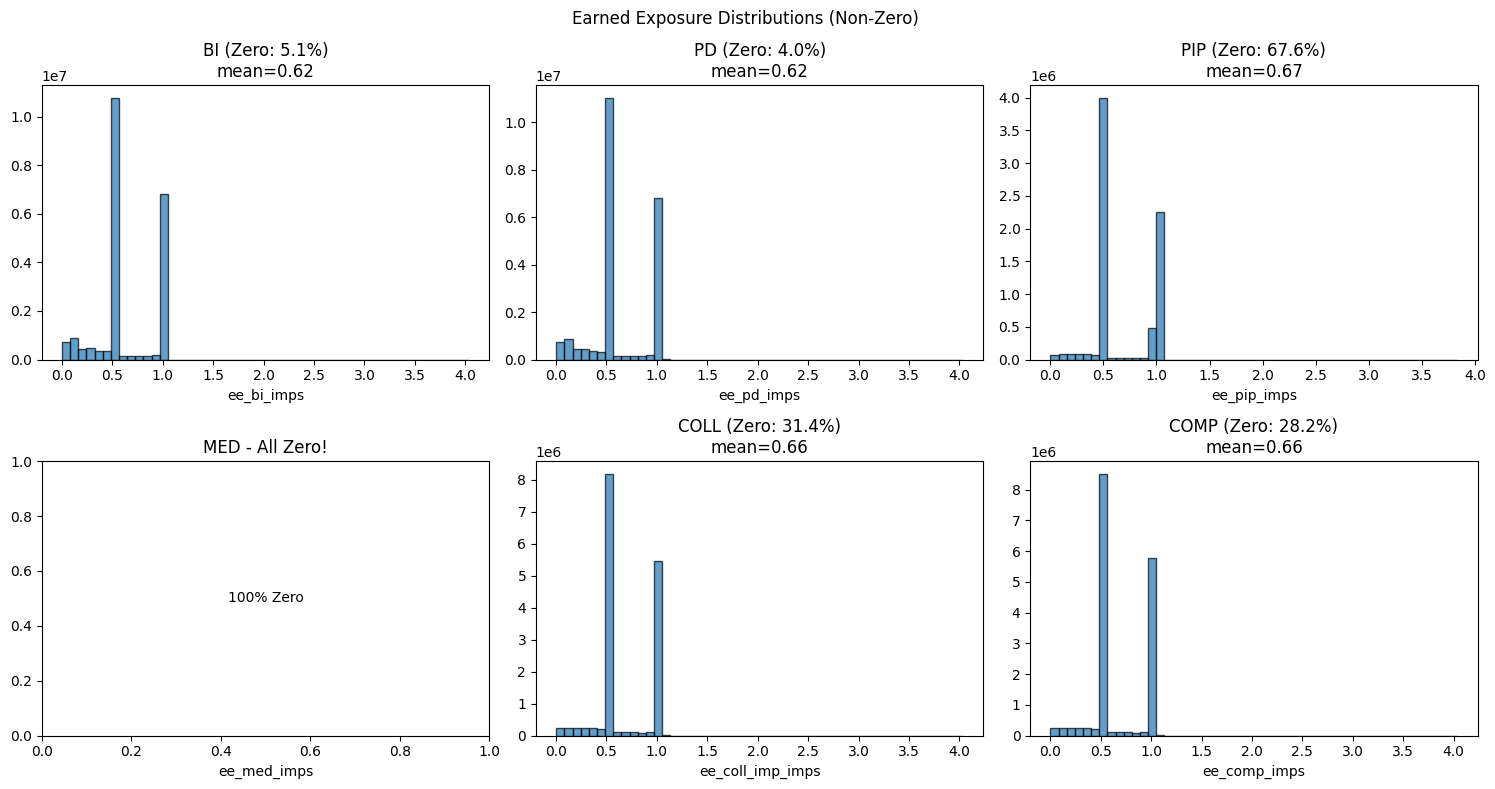

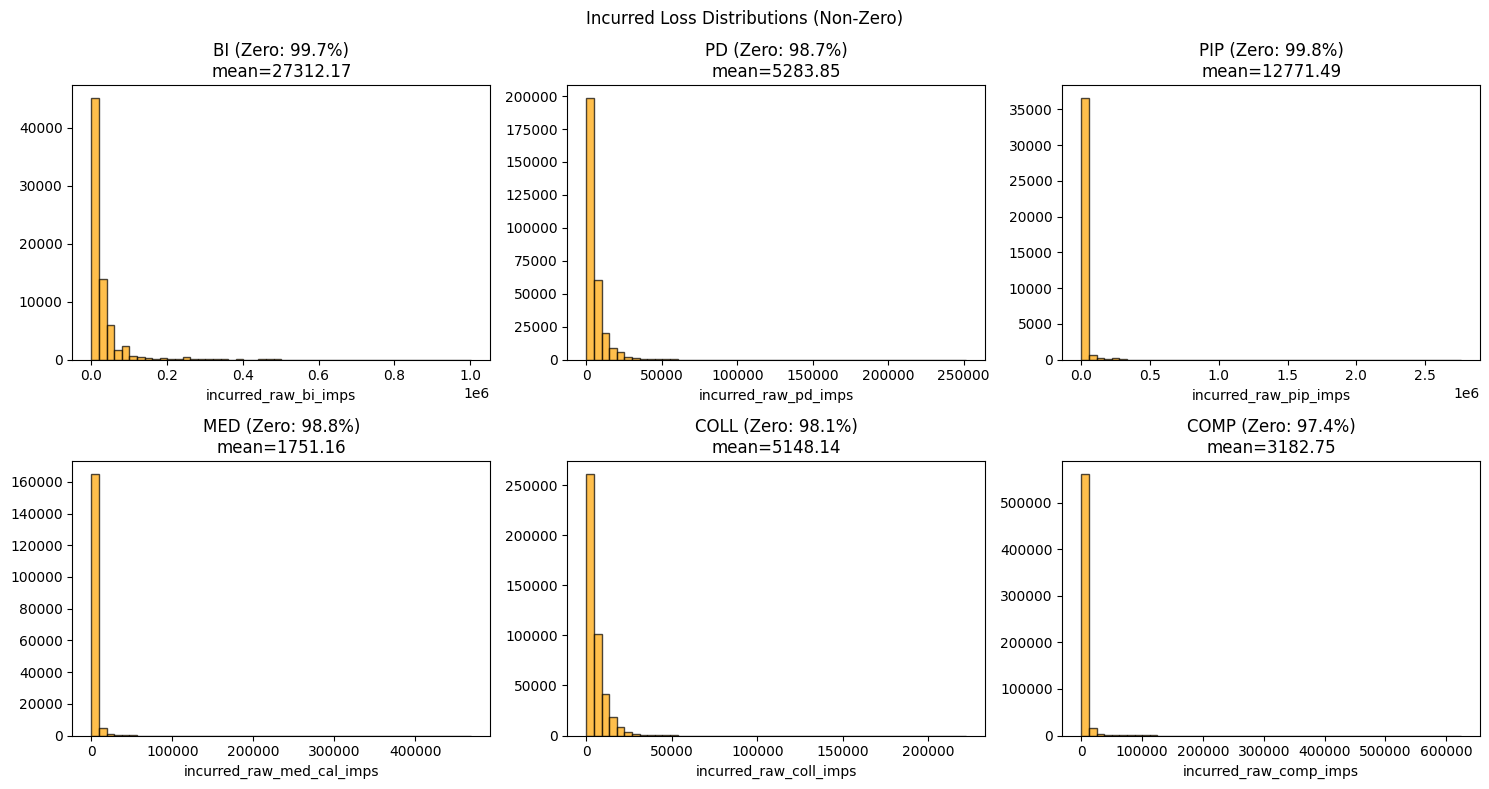

In [3]:
diag.plot_all_coverage_histograms(fc)
diag.plot_incurred_histograms(fc)

/Users/Mach/dev/aps/code/26CF_Dmod_v1/main_folder/03_add_fold/fold_diagnostics.py:138: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/Mach/anaconda3/envs/ds_stack_v1/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


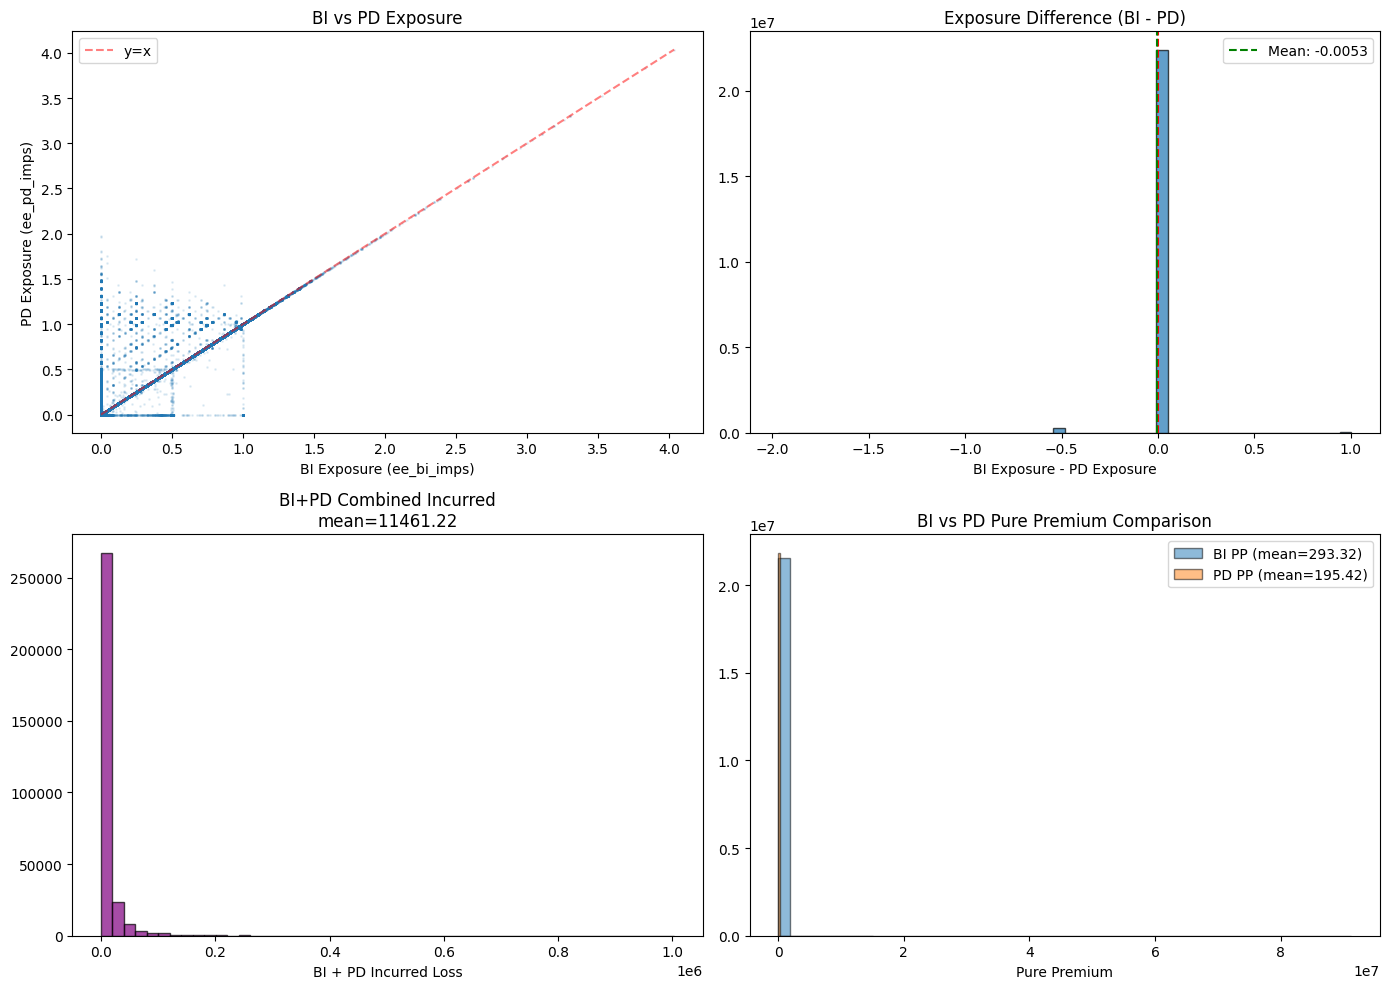

Correlation: 0.9728, same_pct: 98.5%
BI and PD nearly identical - treat as same exposure


In [4]:
diag.analyze_bi_pd_relationship(fc)

In [5]:
diag.show_zero_exposure_stats(fc)

Total records: 22,705,842
Zero exposure counts by coverage:
  BI    (ee_bi_imps): 1,154,153 zeros (5.1%)
  PD    (ee_pd_imps): 900,360 zeros (4.0%)
  PIP   (ee_pip_imps): 15,343,095 zeros (67.6%)
  MED   (ee_med_imps): 22,705,842 zeros (100.0%)
  COLL  (ee_coll_imp_imps): 7,123,525 zeros (31.4%)
  COMP  (ee_comp_imps): 6,411,168 zeros (28.2%)


In [6]:
fc.calculate_pure_premium()
fc.calculate_overall_stats()

  pp_bi: mean=293.32, median=0.00
  pp_pd: mean=195.42, median=0.00
  pp_pip: mean=132.15, median=0.00
  pp_coll: mean=387.70, median=0.00
  pp_comp: mean=201.93, median=0.00
  BI: PP=146.15, Weight=0.2533
  PD: PP=116.34, Weight=0.2556
  PIP: PP=97.85, Weight=0.0934
  COLL: PP=219.74, Weight=0.1942
  COMP: PP=172.67, Weight=0.2035


Running 300 simulations (10 folds)
  10/300 done (117.8s), best so far: seed 7 = 1.5762
  20/300 done (228.8s), best so far: seed 16 = 1.5049
  30/300 done (336.4s), best so far: seed 16 = 1.5049
  40/300 done (449.1s), best so far: seed 40 = 1.3733
  50/300 done (563.1s), best so far: seed 40 = 1.3733
  60/300 done (677.6s), best so far: seed 40 = 1.3733
  70/300 done (789.3s), best so far: seed 40 = 1.3733
  80/300 done (897.8s), best so far: seed 40 = 1.3733
  90/300 done (1005.1s), best so far: seed 40 = 1.3733
  100/300 done (1114.4s), best so far: seed 40 = 1.3733
  110/300 done (1226.1s), best so far: seed 40 = 1.3733
  120/300 done (1335.5s), best so far: seed 40 = 1.3733
  130/300 done (1453.9s), best so far: seed 40 = 1.3733
  140/300 done (1571.9s), best so far: seed 133 = 1.3638
  150/300 done (1692.4s), best so far: seed 133 = 1.3638
  160/300 done (1804.7s), best so far: seed 133 = 1.3638
  170/300 done (1912.6s), best so far: seed 133 = 1.3638
  180/300 done (2019.1s), b

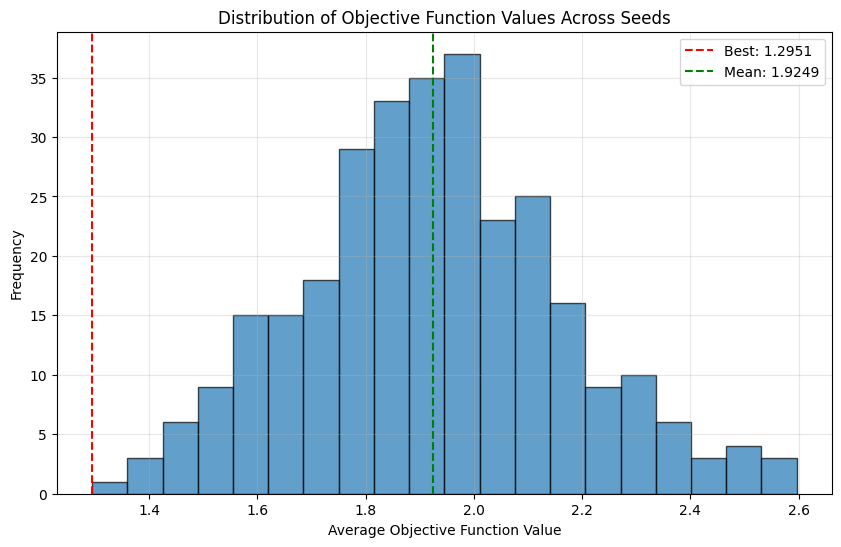

In [7]:
results_df = fc.run_simulations()
diag.plot_objective_distribution(results_df)

In [8]:
fc.get_best_seed()
fc.apply_best_seed()

Best seed: 222 (objective=1.2951)
Fold distribution:
fold
1     2279525
2     2271005
3     2268245
4     2271221
5     2266625
6     2271464
7     2268113
8     2271441
9     2272527
10    2265676
Name: count, dtype: int64


In [9]:
fc.validate_folds()

--- Record Counts ---
  Fold 1: 2,279,525 records (10.0%)
  Fold 2: 2,271,005 records (10.0%)
  Fold 3: 2,268,245 records (10.0%)
  Fold 4: 2,271,221 records (10.0%)
  Fold 5: 2,266,625 records (10.0%)
  Fold 6: 2,271,464 records (10.0%)
  Fold 7: 2,268,113 records (10.0%)
  Fold 8: 2,271,441 records (10.0%)
  Fold 9: 2,272,527 records (10.0%)
  Fold 10: 2,265,676 records (10.0%)
--- Superpolicy Counts ---
  Fold 1: 421,900 superpolicies (10.0%)
  Fold 2: 421,900 superpolicies (10.0%)
  Fold 3: 421,900 superpolicies (10.0%)
  Fold 4: 421,900 superpolicies (10.0%)
  Fold 5: 421,900 superpolicies (10.0%)
  Fold 6: 421,900 superpolicies (10.0%)
  Fold 7: 421,900 superpolicies (10.0%)
  Fold 8: 421,900 superpolicies (10.0%)
  Fold 9: 421,900 superpolicies (10.0%)
  Fold 10: 421,901 superpolicies (10.0%)
--- Objective Function by Fold ---
  Fold 1: 1.7913
  Fold 2: 1.0904
  Fold 3: 1.5874
  Fold 4: 1.0236
  Fold 5: 1.2934
  Fold 6: 1.1595
  Fold 7: 1.4181
  Fold 8: 0.7388
  Fold 9: 1.2363
 

In [10]:
df_out = fc.export()

Simulation results saved: /Users/Mach/dev/aps/data/2026_Dmodel_data/fold_superpolicy/simulation_results_10fold.csv
Fold assignments saved: /Users/Mach/dev/aps/data/2026_Dmodel_data/fold_superpolicy/car_master_dataset_10fold_sp.parquet
Shape: (22705842, 8)
